# Evaluation
## Offline evaluation datasets
### Retrieval evaluation data
In order to evaluate the performance of the search function, we generate a synthetic dataset that models how we want the function to behave. It is generated through a reverse-engineering process: for every document in a sample, an LLM is prompted to come up with realistic queries that could be asked about the content found in that document. The output of this process is a set of query-document pairs that is referred to as the ground truth.

Later in the evaluation process, we will measure how well the search functionality peforms at retrieving the ground truth document given the associated query as input.

In [1]:
from wikifin_rag.factories import dict_factory
from wikifin_rag.db_client import DocumentsDBClient

In [2]:
def load_wikifin_data(factory=dict_factory):
    db_client = DocumentsDBClient()

    with db_client.get_db_connection() as con:
        con.row_factory = factory

        cur = con.execute("""
            SELECT
                c.document_id || '_' || c.chunk_id AS id,
                d.title,
                d.section,
                c.content,
                c.embedding,
                d.source_url
            FROM chunks c
            JOIN documents d
            ON c.document_id = d.id
            WHERE d.language = 'nl';
        """)

    return cur.fetchall()

In [3]:
documents = load_wikifin_data()

In [4]:
from pydantic import BaseModel

class Questions(BaseModel):
    questions: list[str]

In [5]:
data_gen_instructions = """
You emulate a student or young professional who has questions about personal finance.
Formulate {} questions this person might ask based on a document passage.
The passage should contain the answer to the questions, and the questions should be complete and not too short.
If possible, use as fewer words as possible from the record.

The output should resemble how people ask questions
on the internet. Not too formal, not too short, not too long.
""".strip()

In [6]:
from dotenv import load_dotenv
from openai import OpenAI
from wikifin_rag.evaluation_utils import llm_structured_retry

In [7]:
load_dotenv(override=True)
openai_client = OpenAI()

In [8]:
def generate_document_ground_truth(doc, n=5):
    """
    Generates n questions based in the input document's content.
    """
    user_prompt = doc['content']

    out, usage = llm_structured_retry(
        openai_client,
        data_gen_instructions.format(n),
        user_prompt,
        Questions
    )

    results = []

    for q in out.questions:
        results.append({
            "question": q,
            "document": doc["id"]
        })

    return results, usage

In [9]:
from concurrent.futures import ThreadPoolExecutor
from wikifin_rag.evaluation_utils import map_progress, calculate_total_cost
import pandas as pd
from wikifin_rag.config import PROJECT_ROOT
from pathlib import Path
import numpy as np
import os

In [10]:
def generate_corpus_ground_truth(documents, n=5, file_path=PROJECT_ROOT / "data" / "evals" / "ground_truth-new.csv"):
    """
    Creates a dataset of n questions per document in the input corpus.
    Output is saved to a CSV file.
    """
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = map_progress(pool, documents, lambda doc: generate_document_ground_truth(doc, n=n))

    ground_truth = []
    usages = []

    for records, usage in results:
        ground_truth.extend(records)
        usages.append(usage)

    # total_cost = calculate_total_cost(usages)

    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    df_ground_truth = pd.DataFrame(ground_truth)
    df_ground_truth.to_csv(file_path, index=False)


In [11]:
# number of documents to use
n_documents = 500

# number of question to generate per document
n_questions = 5

# file path for the generated ground truth dataset
ground_truth_file_path = PROJECT_ROOT / "data" / "evals" / "ground_truth-new.csv"

In [12]:
# TODO: change to True to force a ground truth data refresh
refresh_ground_truth = False

In [13]:
if refresh_ground_truth or not os.path.exists(ground_truth_file_path):
    # use a random sample of documents to generate the ground truth dataset
    sample = np.random.choice(documents, size=n_documents, replace=False)

    generate_corpus_ground_truth(documents=sample, n=n_questions, file_path=ground_truth_file_path)

  0%|          | 0/500 [00:00<?, ?it/s]

In [14]:
test_split = .25

In [15]:
df_ground_truth = pd.read_csv(ground_truth_file_path)
df_ground_truth.reset_index(names="index", inplace=True)
df_ground_truth_eval = df_ground_truth.sample(frac=test_split, random_state=1)
df_ground_truth_train = df_ground_truth.loc[~df_ground_truth.index.isin(df_ground_truth_eval.index)]

In [16]:
ground_truth = df_ground_truth_train.to_dict(orient="records")

## Retrieval metrics
### Text Search Optimization
The text search function returns the documents that have the highest amount of overlap with the search query. Overlap corresponds to the frequency with which individual query terms appear in a document. The more often the query terms appear in the document, the higher the document is ranked by the search function.

Occurences of overlapping terms are weighted differently depending on where they appear in the document. A change in the weighting scheme will therefore impact the document ranking for a given search query, and potentially produce a different result set.

We optimize the retrieval system based on the mean reciprocal rank (MRR) by adjusting the boosting weights. Our goal is to identify the set of weights that yields the highest MRR on the previously generated ground truth dataset. MRR considers how highly the golden truth document is ranked by the search function for each query in the dataset.

In [17]:
from wikifin_rag.evaluation_utils import evaluate
from wikifin_rag.search_utils import build_text_index, text_search
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import pickle

In [18]:
ts_index = build_text_index(documents=documents)

In [19]:
def ts_objective(params):
    metrics = evaluate(
        ground_truth=ground_truth,
        search_function=lambda query: text_search(query=query, index=ts_index, boost_dict=params)
    )

    return {
        'loss': -round(metrics['mrr'], 4),
        'status': STATUS_OK,
        'params': params,
        'metrics': metrics
    }

In [20]:
n_evals = 25

In [21]:
ts_trials_file_path = PROJECT_ROOT / "data" / "evals" / "ts_trials.pkl"

In [22]:
# TODO: change to True to force a ground truth data refresh
refresh_search_optimization = False

In [23]:
ts_search_space = {
    "title": hp.uniform("title", 0, 20),
    "description": hp.uniform("description", 0, 20),
    "section": hp.uniform("section", 0, 20),
    "content": hp.uniform("content", 0, 20)
}

In [24]:
if refresh_search_optimization or not os.path.exists(ts_trials_file_path):
    ts_trials_file_path.parent.mkdir(parents=True, exist_ok=True)
    
    trials = Trials()

    best_params = fmin(
        fn=ts_objective,
        space=ts_search_space,
        algo=tpe.suggest,
        max_evals=n_evals,
        trials=trials
    )

    trials_data = [{
        'id': trial['tid'],
        'mrr': trial['result']['metrics']['mrr'],
        'hit_rate': trial['result']['metrics']['hit_rate'],
        'params': trial['result']['params'],
    } for trial in trials.trials]
    
    with open(ts_trials_file_path, "wb") as file:
        pickle.dump((best_params, trials_data), file)

  0%|          | 0/25 [00:00<?, ?trial/s, best loss=?]

  0%|          | 0/1875 [00:00<?, ?it/s]

  4%|▍         | 1/25 [00:04<01:54,  4.78s/trial, best loss: -0.4463]

  0%|          | 0/1875 [00:00<?, ?it/s]

  8%|▊         | 2/25 [00:09<01:50,  4.81s/trial, best loss: -0.4463]

...

 92%|█████████▏| 23/25 [01:58<00:10,  5.47s/trial, best loss: -0.4463]

  0%|          | 0/1875 [00:00<?, ?it/s]

 96%|█████████▌| 24/25 [02:04<00:05,  5.52s/trial, best loss: -0.4463]

  0%|          | 0/1875 [00:00<?, ?it/s]

100%|██████████| 25/25 [02:09<00:00,  5.20s/trial, best loss: -0.4463]


In [25]:
with open(ts_trials_file_path, "rb") as file:
    ts_params, ts_trials_data = pickle.load(file)

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
ts_trials_data_df = pd.DataFrame(ts_trials_data)

In [28]:
ts_trials_data_df_long = ts_trials_data_df.melt(
    id_vars=ts_trials_data_df.drop(["mrr", "hit_rate"], axis=1).columns,
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

In [29]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
sns.set_context("notebook")

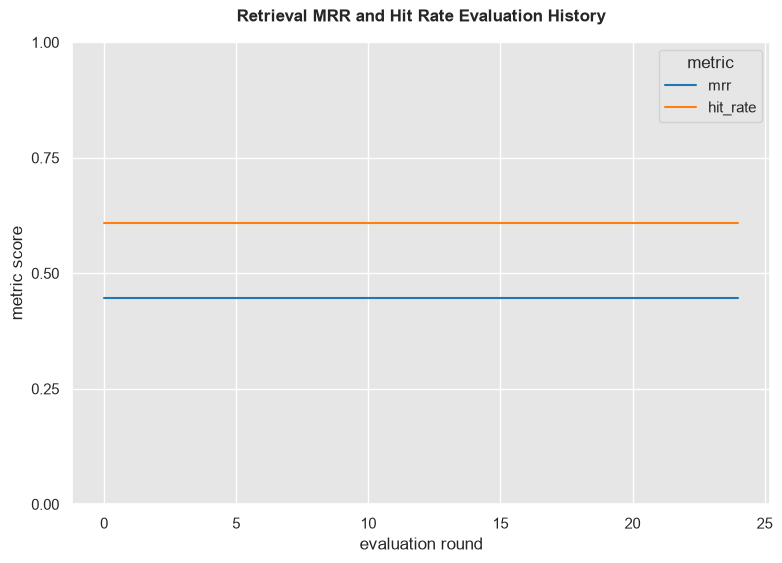

In [30]:
plt.figure(figsize=(9, 6))
plt.title("Retrieval MRR and Hit Rate Evaluation History", fontweight="bold", pad=15)
plt.xlabel("evaluation round")
plt.ylabel("metric score")

g = sns.lineplot(
    data=ts_trials_data_df_long,
    x="id",
    y="value",
    hue="metric"
)

g.set(ylim=(0, 1), yticks=[0, 0.25, 0.5, 0.75, 1])

plt.show()

In [31]:
ts_best_metrics = max(ts_trials_data, key=lambda d: d['mrr'])

In [32]:
print(f"Text search MRR: {round(ts_best_metrics['mrr'], 4)} | Hit Rate: {round(100 * ts_best_metrics['hit_rate'], 2)}%")

Text search MRR: 0.4463 | Hit Rate: 60.85%


### Vector Search

In [33]:
from wikifin_rag.search_utils import build_vector_index, vector_search, load_vector_index
from wikifin_rag.factories import embedding_factory
from wikifin_rag.embedder import Embedder
from hyperopt.pyll import scope

In [34]:
documents = load_wikifin_data(embedding_factory)
embeddings = [doc.pop('embedding') for doc in documents]

In [35]:
embedder = Embedder()

In [36]:
vs_index = build_vector_index(vectors=embeddings, documents=documents)

In [37]:
def vs_objective(params):
    vs_index = build_vector_index(vectors=embeddings, documents=documents, **params)

    metrics = evaluate(
        ground_truth=ground_truth,
        search_function=lambda query: vector_search(index=vs_index, query=query, embedder=embedder)
    )

    return {
        'loss': -round(metrics['mrr'], 4),
        'status': STATUS_OK,
        'params': params,
        'metrics': metrics
    }

In [38]:
mode_options = ["hnsw", "lsh", "ivf"]
m_options = [8, 12, 16, 24, 32]
ef_construction_options = [50, 100, 200, 400]
ef_search_options = [10, 20, 40, 80, 160, 320]

n_clusters_options = [None, 32, 64, 128, 256, 512]


In [39]:
vs_search_space = hp.pchoice(
    "mode",
    [
        # HNSW
        (0.8, {
            "mode": "hnsw",
            "m": hp.choice("m", [8, 12, 16, 24, 32]),
            "ef_construction": hp.choice(
                "ef_construction",
                [50, 100, 200, 400],
            ),
            "ef_search": hp.choice(
                "ef_search",
                [10, 20, 40, 80, 160, 320],
            )
        }),

        # LSH
        (0.1, {
            "mode": "lsh",
            "n_tables": scope.int(hp.quniform("lsh_n_tables", 2, 32, 1)),
            "hash_size": scope.int(hp.quniform("lsh_hash_size", 8, 24, 1)),
            "n_probe": scope.int(hp.quniform("lsh_n_probe", 0, 2, 1)),
        }),

        # IVF
        (0.1, {
            "mode": "ivf",
            "n_clusters": hp.choice(
                "n_clusters",
                [None, 32, 64, 128, 256, 512]
            ),
            "n_probe_clusters": scope.int(hp.quniform(
                "n_probe_clusters", 1, 32, 1
            )),
        }),
    ]
)

In [40]:
vs_trials_file_path = PROJECT_ROOT / "data" / "evals" / "vs_trials.pkl"

In [41]:
if refresh_search_optimization or not os.path.exists(vs_trials_file_path):
    vs_trials_file_path.parent.mkdir(parents=True, exist_ok=True)
    
    trials = Trials()

    best_params = fmin(
        fn=vs_objective,
        space=vs_search_space,
        algo=tpe.suggest,
        max_evals=n_evals,
        trials=trials
    )

    trials_data = [{
        'id': trial['tid'],
        'mrr': trial['result']['metrics']['mrr'],
        'hit_rate': trial['result']['metrics']['hit_rate'],
        'params': trial['result']['params']
    } for trial in trials.trials]

    with open(vs_trials_file_path, "wb") as file:
        pickle.dump((best_params, trials_data), file)

  0%|          | 0/25 [00:00<?, ?trial/s, best loss=?]

  0%|          | 0/1875 [00:00<?, ?it/s]

  4%|▍         | 1/25 [00:15<06:17, 15.72s/trial, best loss: -0.6016]

  0%|          | 0/1875 [00:00<?, ?it/s]

  8%|▊         | 2/25 [00:26<04:54, 12.82s/trial, best loss: -0.6016]

...

 92%|█████████▏| 23/25 [14:38<04:02, 121.29s/trial, best loss: -0.6089]

  0%|          | 0/1875 [00:00<?, ?it/s]

 96%|█████████▌| 24/25 [16:43<02:02, 122.50s/trial, best loss: -0.6089]

  0%|          | 0/1875 [00:00<?, ?it/s]

100%|██████████| 25/25 [17:39<00:00, 42.36s/trial, best loss: -0.6089] 


In [42]:
with open(vs_trials_file_path, "rb") as file:
    _, vs_trials_data = pickle.load(file)

In [43]:
vs_trials_data_df = pd.DataFrame(vs_trials_data)

In [44]:
vs_trials_data_df_long = vs_trials_data_df.melt(
    id_vars=vs_trials_data_df.drop(["mrr", "hit_rate"], axis=1).columns,
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

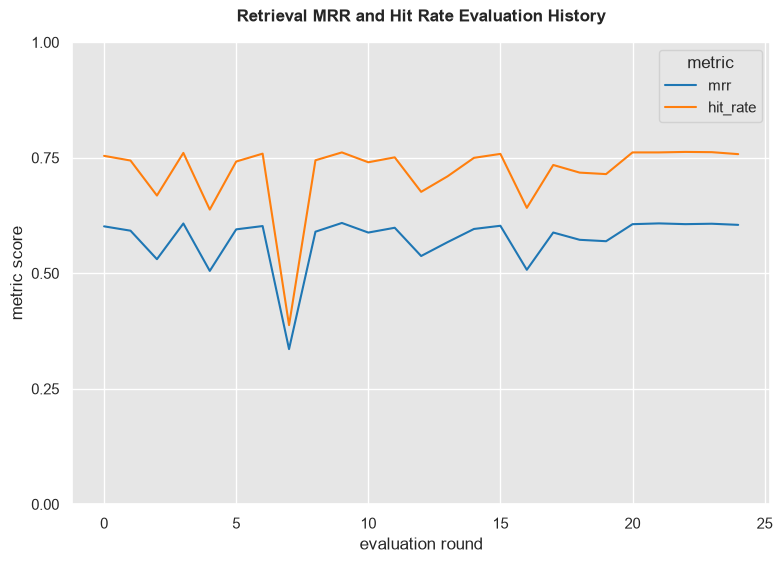

In [45]:
plt.figure(figsize=(9, 6))
plt.title("Retrieval MRR and Hit Rate Evaluation History", fontweight="bold", pad=15)
plt.xlabel("evaluation round")
plt.ylabel("metric score")

g = sns.lineplot(
    data=vs_trials_data_df_long,
    x="id",
    y="value",
    hue="metric"
)

g.set(ylim=(0, 1), yticks=[0, 0.25, 0.5, 0.75, 1])

plt.show()

In [46]:
vs_best_metrics = max(vs_trials_data, key=lambda d: d['mrr'])

In [47]:
print(f"Vector search MRR: {round(vs_best_metrics['mrr'], 4)} | Hit Rate: {round(100 * vs_best_metrics['hit_rate'], 2)}%")

Vector search MRR: 0.6089 | Hit Rate: 76.16%


### Hybrid search

In [48]:
from wikifin_rag.search_utils import rrf_hybrid_search

In [49]:
ts_index = build_text_index(documents)

In [50]:
def optimized_text_search(query, num_results=5):
    return text_search(query=query, index=ts_index, num_results=num_results, boost_dict=ts_params)

In [51]:
with open(PROJECT_ROOT / "data" / "evals" / "ts_index_params.pkl", "wb") as file:
    pickle.dump(ts_params, file)

In [52]:
vs_best_params = max(vs_trials_data, key=lambda d: d['mrr'])['params']
vs_index = build_vector_index(embeddings, documents, **vs_best_params)

In [53]:
def optimized_vector_search(query, num_results=5):
    return vector_search(query=query, index=vs_index, embedder=embedder, num_results=num_results)

In [54]:
with open(PROJECT_ROOT / "data" / "evals" / "vs_index_params.pkl", "wb") as file:
    pickle.dump(vs_best_params, file)

In [55]:
def hybrid_search(query, num_results=5):
    ts_results = optimized_text_search(query=query, num_results=num_results)
    vs_results = optimized_vector_search(query=query, num_results=num_results)

    return rrf_hybrid_search([ts_results, vs_results], num_results=num_results)

In [56]:
hs_metrics = evaluate(ground_truth=ground_truth, search_function=hybrid_search)

  0%|          | 0/1875 [00:00<?, ?it/s]

In [57]:
print(f"Hybrid search MRR: {round(hs_metrics['mrr'], 4)} | Hit Rate: {round(100 * hs_metrics['hit_rate'], 2)}%")

Hybrid search MRR: 0.5839 | Hit Rate: 76.75%


In [58]:
evaluation_rounds = 10
evaluation_sample_size = 200

search_functions = [optimized_text_search, optimized_vector_search, hybrid_search]

eval_results = []

for i in range(evaluation_rounds):
    sample_data = df_ground_truth_eval.sample(n=evaluation_sample_size, random_state=i).to_dict(orient='records')

    for search_function in search_functions:
        fold_metrics = evaluate(sample_data, search_function=search_function)
        fold_metrics['id'] = i
        fold_metrics['function'] = search_function.__name__

        eval_results.append(fold_metrics)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [59]:
metrics_df = pd.DataFrame(eval_results)

In [60]:
metrics_df_long = metrics_df.melt(
    id_vars=["id", "function"],
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

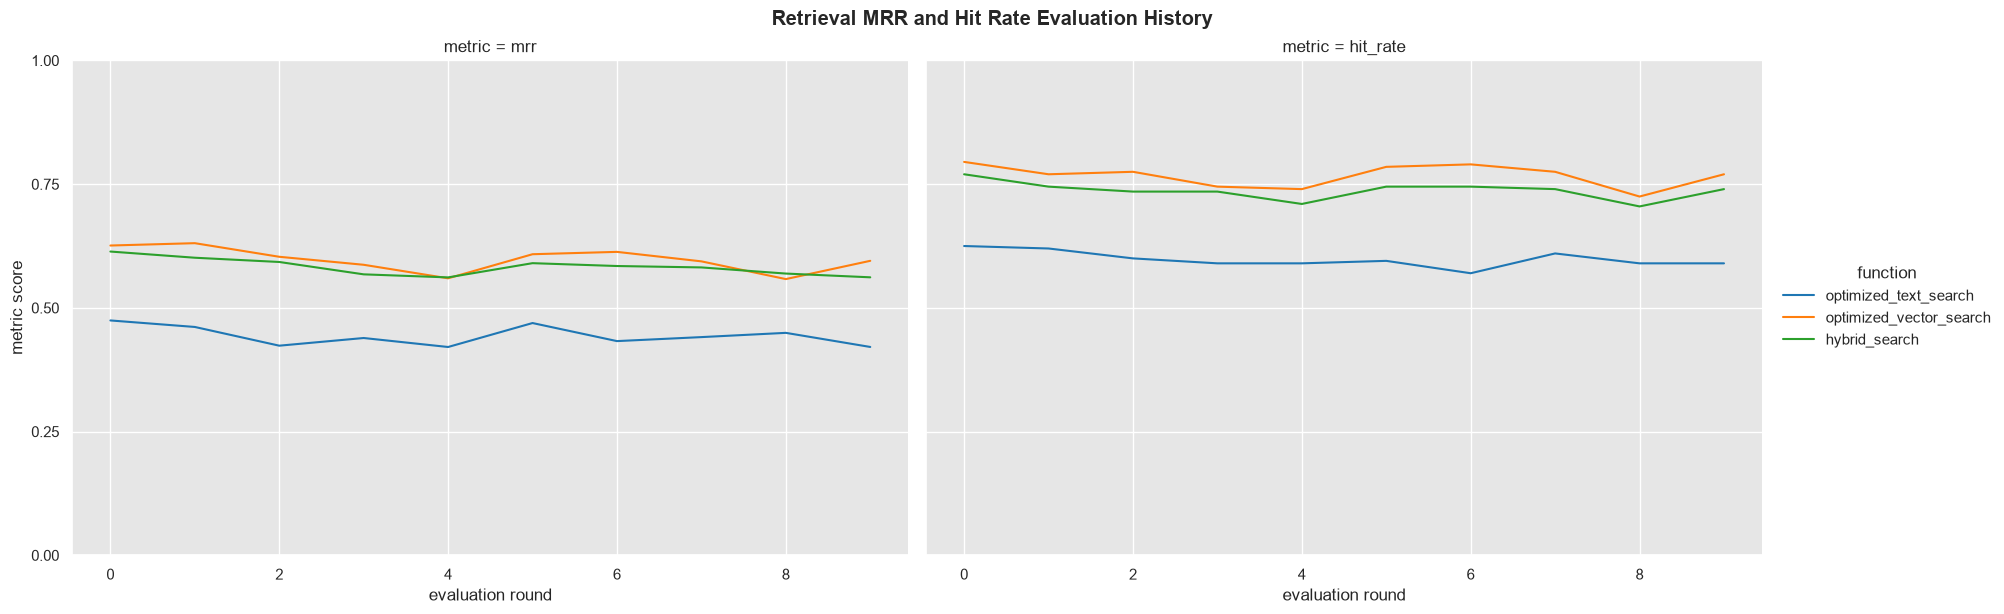

In [61]:
metrics_df_long = metrics_df.melt(
    id_vars=["id", "function"],
    value_vars=["mrr", "hit_rate"],
    var_name="metric"
)

g = sns.relplot(
    data=metrics_df_long,
    x="id",
    y="value",
    col="metric",
    hue="function",
    kind="line",
    height=6,
    aspect=1.5
)

g.set(ylim=(0, 1), yticks=[0, 0.25, 0.5, 0.75, 1])


g.figure.suptitle(
    "Retrieval MRR and Hit Rate Evaluation History",
    fontweight="bold",
    y=1.02
)

g.set_axis_labels("evaluation round", "metric score")

plt.show()

In [62]:
openai_client.close()